In [12]:
from google.colab import files
uploaded=files.upload()

Saving air_quality_data.csv to air_quality_data (1).csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(10,5)

In [14]:
df = pd.read_csv("/content/air_quality_data.csv")

df.head()

,City,Country,AQI,PM2.5,PM10,NO2,SO2,CO,Traffic_Index,Industrial_Index,Year
0,Delhi,India,280,180,250,65,28,1.8,95,90,2020
1,Delhi,India,290,190,260,68,30,1.9,97,91,2021
2,Delhi,India,300,200,270,70,31,2.0,98,92,2022
3,Mumbai,India,180,110,160,45,18,1.2,80,70,2020
4,Mumbai,India,190,115,170,48,20,1.3,82,72,2021


In [15]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              30 non-null     object 
 1   Country           30 non-null     object 
 2   AQI               30 non-null     int64  
 3   PM2.5             30 non-null     int64  
 4   PM10              30 non-null     int64  
 5   NO2               30 non-null     int64  
 6   SO2               30 non-null     int64  
 7   CO                30 non-null     float64
 8   Traffic_Index     30 non-null     int64  
 9   Industrial_Index  30 non-null     int64  
 10  Year              30 non-null     int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 2.7+ KB


,0
City,0
Country,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Traffic_Index,0
Industrial_Index,0


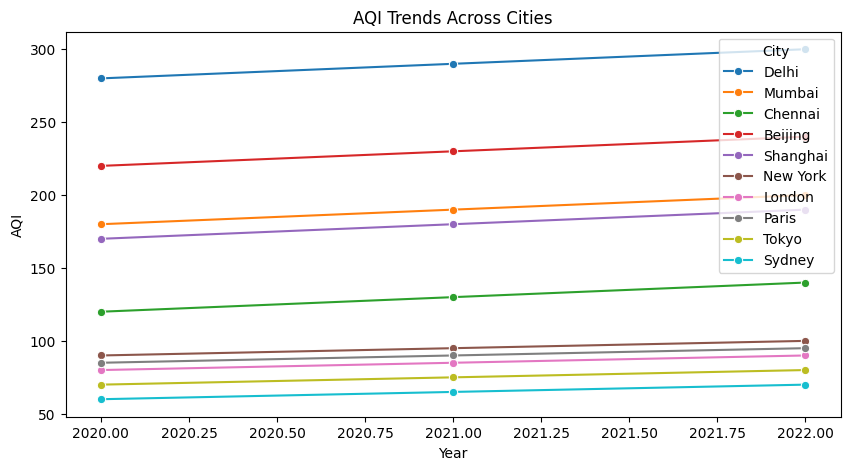

In [16]:
sns.lineplot(data=df,
             x='Year',
             y='AQI',
             hue='City',
             marker='o')

plt.title("AQI Trends Across Cities")
plt.show()

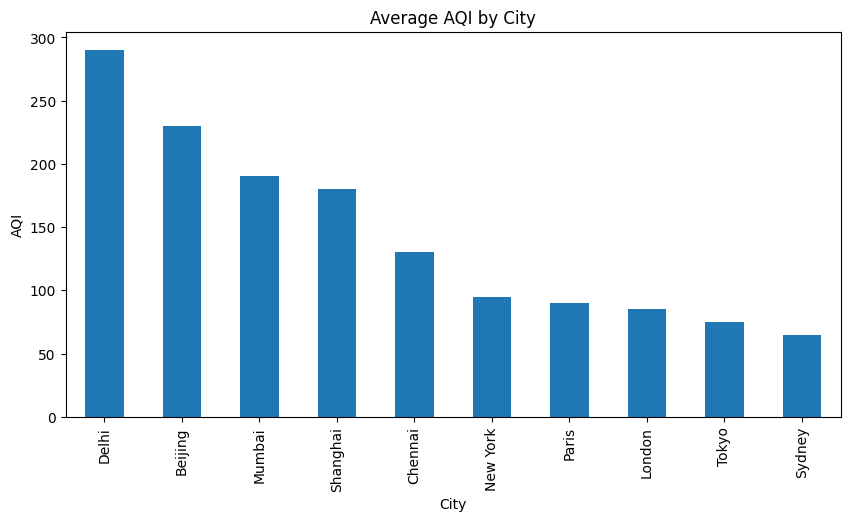

In [17]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

city_aqi.plot(kind='bar')

plt.title("Average AQI by City")
plt.ylabel("AQI")
plt.show()

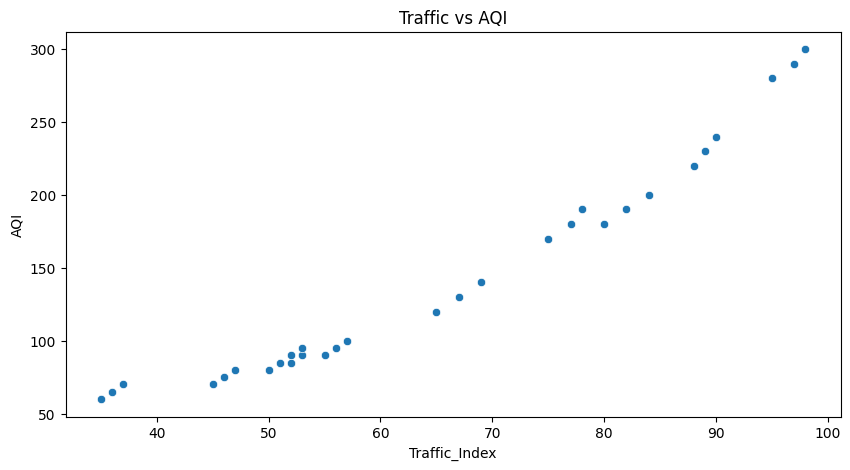

In [18]:
sns.scatterplot(
    data=df,
    x='Traffic_Index',
    y='AQI'
)

plt.title("Traffic vs AQI")
plt.show()


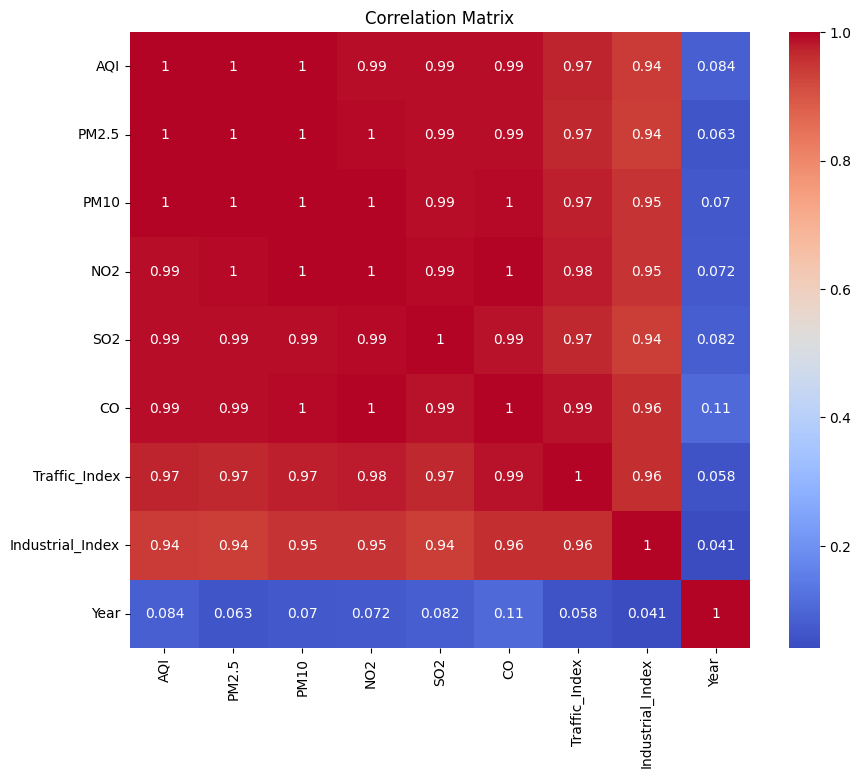

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

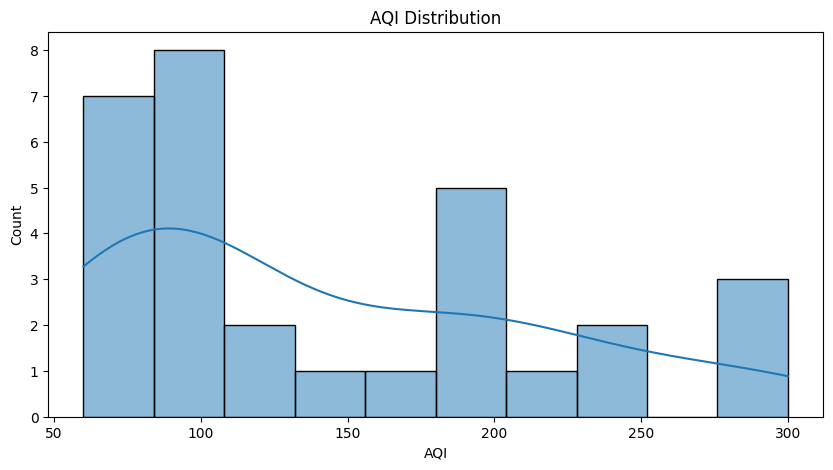

In [20]:
sns.histplot(
    df['AQI'],
    bins=10,
    kde=True
)

plt.title("AQI Distribution")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['PM2.5','PM10','NO2','SO2',
        'CO','Traffic_Index',
        'Industrial_Index']]

y = df['AQI']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2 Score:",r2_score(y_test,pred))

R2 Score: 0.9960548218155758


In [22]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.coef_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,CO,8.484215
3,SO2,3.758333
1,PM10,0.916910
5,Traffic_Index,0.818355
0,PM2.5,0.761253
6,Industrial_Index,-0.055608
2,NO2,-4.693734
